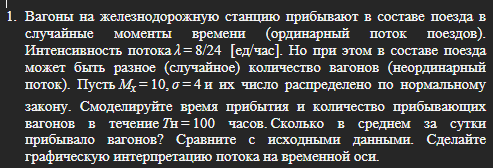

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np


lam = 8/24
Mx = 10
sigma = 4
T = 100
np.random.seed(37)
times = []
t = 0

while True:
    dt = -1 / lam * math.log(np.random.uniform(0, 1))
    t += dt
    if t > T:
        break
    times.append(t)

times = np.array(times)
n_trains = len(times)

wagons_raw = np.random.normal(Mx, sigma, n_trains)
wagons = np.round(wagons_raw).astype(int)
wagons = np.maximum(wagons, 0)
total_wagons = wagons.sum()
avg = total_wagons / T * 24

print(f"Промоделировано часов: {T}")
print(f"Количество поездов: {n_trains}")
print(f"Ожидалось поездов (теория): {lam * T:.2f}")
print(f"Вагонов: {total_wagons}")
print(f"Среднее число вагонов в поезде: {wagons.mean():.2f} (теория {Mx})")
print(f"Среднее число вагонов в сутки: {avg:.2f} (теория {lam * 24 * Mx:.2f})")

Промоделировано часов: 100
Количество поездов: 37
Ожидалось поездов (теория): 33.33
Вагонов: 378
Среднее число вагонов в поезде: 10.22 (теория 10)
Среднее число вагонов в сутки: 90.72 (теория 80.00)


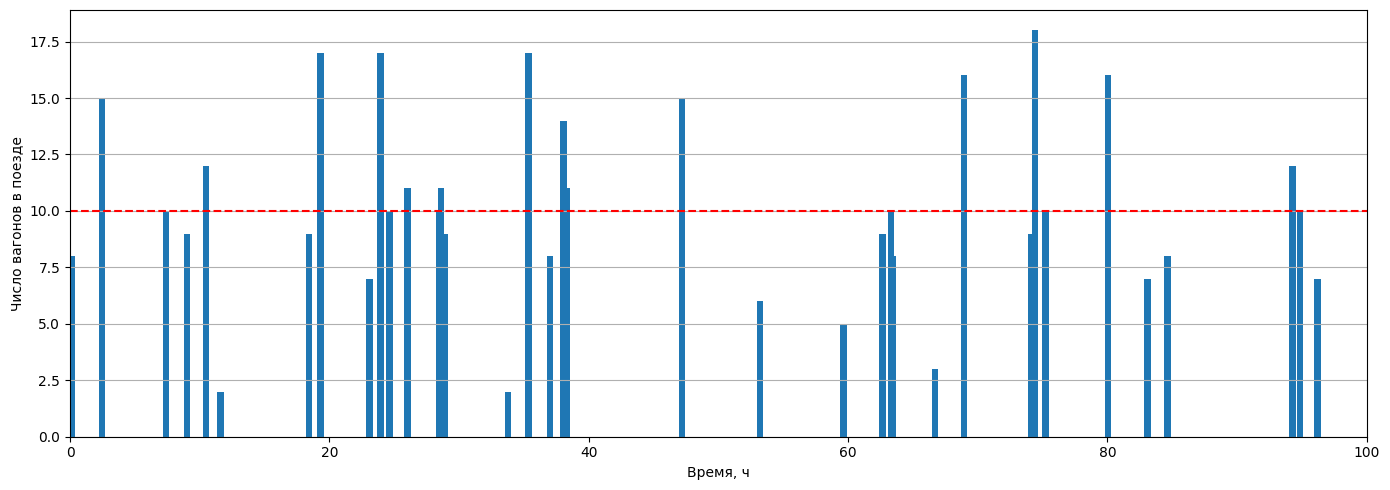

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(times, wagons, width=0.5)

ax.set_xlim(0, T)
ax.set_xlabel('Время, ч')
ax.set_ylabel('Число вагонов в поезде')
ax.grid(True, axis='y')

ax.axhline(Mx, color='red', linestyle='--')

plt.tight_layout()
plt.show()

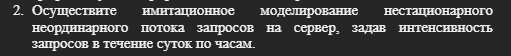

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(42)

lambda_hourly = np.array([1,  1,  1,  1, 2,  3,  5,  8, 12, 15, 18, 20, 20, 18, 17, 16, 15, 13, 10, 8, 6,  4,  3,  2], dtype=float)

T = 24
lam_max = lambda_hourly.max()
print(f"λ_max = {lam_max}")

def lam_of_t(t):
    h = int(t) % 24
    return lambda_hourly[h]

mean_dt = 1.0 / lam_max
t = 0.0
candidates = []
while True:
    dt = -mean_dt * math.log(np.random.uniform(0, 1))
    t += dt
    if t > T:
        break
    candidates.append(t)

accepted = []
for tc in candidates:
    p_accept = lam_of_t(tc) / lam_max
    if np.random.uniform(0, 1) < p_accept:
        accepted.append(tc)

accepted = np.array(accepted)
n_requests = len(accepted)
print(f"Число кандидатов: {len(candidates)}")
print(f"Принято запросов: {n_requests}")

Mx_w, sigma_w = 5, 2
units_raw = np.random.normal(Mx_w, sigma_w, n_requests)
units = np.maximum(np.round(units_raw).astype(int), 0)

total_units = units.sum()
print(f"Всего транзакций: {total_units}")


expected_requests = lambda_hourly.sum()
expected_units = expected_requests * Mx_w
print(f"Ожидалось запросов (теория): {expected_requests:.1f}")
print(f"Ожидалось транзакций (теория): {expected_units:.1f}")
print(f"Отношение имитация/теория: {n_requests / expected_requests:.3f}")

λ_max = 20.0
Число кандидатов: 460
Принято запросов: 230
Всего транзакций: 1135
Ожидалось запросов (теория): 219.0
Ожидалось транзакций (теория): 1095.0
Отношение имитация/теория: 1.050


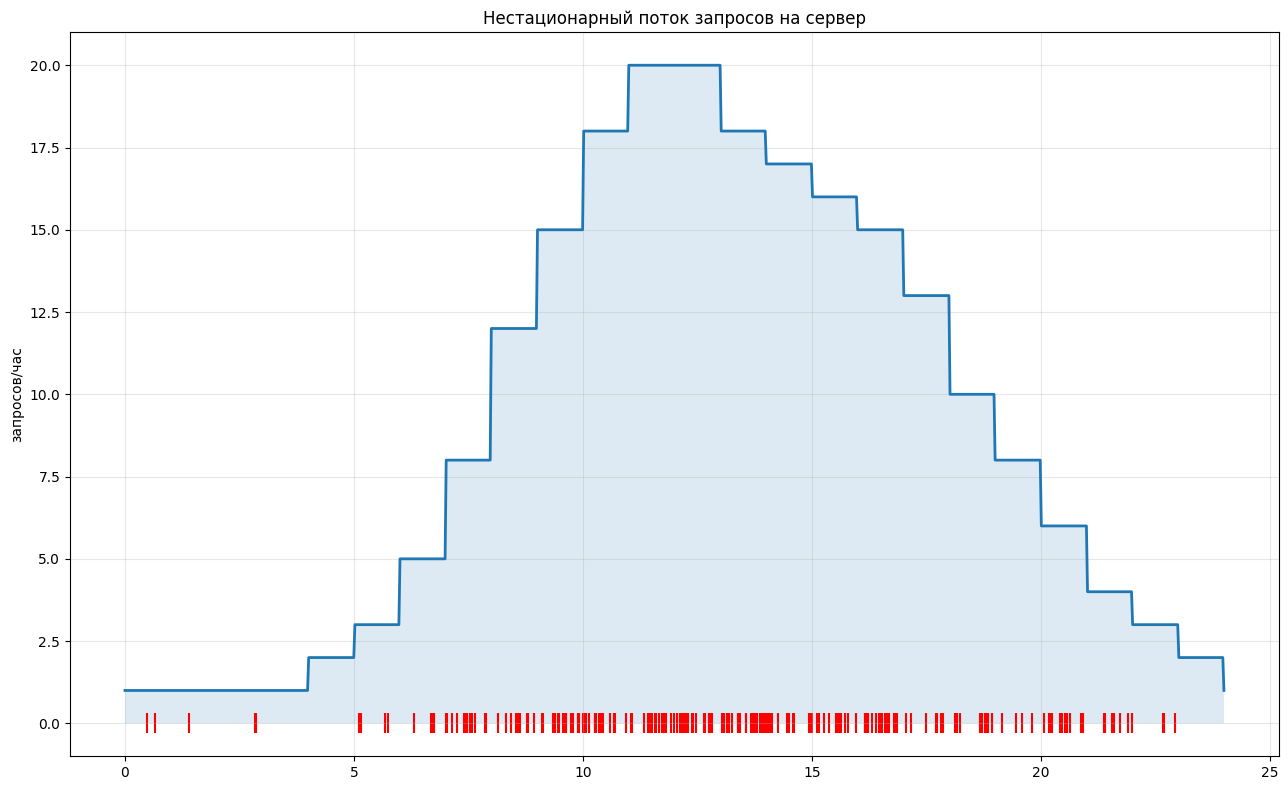

In [ ]:
fig, ax = plt.subplots(figsize=(13, 8), sharex=True)

t_grid = np.linspace(0, 24, 1000)
lam_grid = [lam_of_t(t) for t in t_grid]
ax.plot(t_grid, lam_grid, linewidth=2)
ax.fill_between(t_grid, lam_grid, alpha=0.15)
ax.scatter(accepted, np.zeros_like(accepted), marker='|', s=200, color='red')
ax.set_ylabel('запросов/час')
ax.set_title('Нестационарный поток запросов на сервер')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

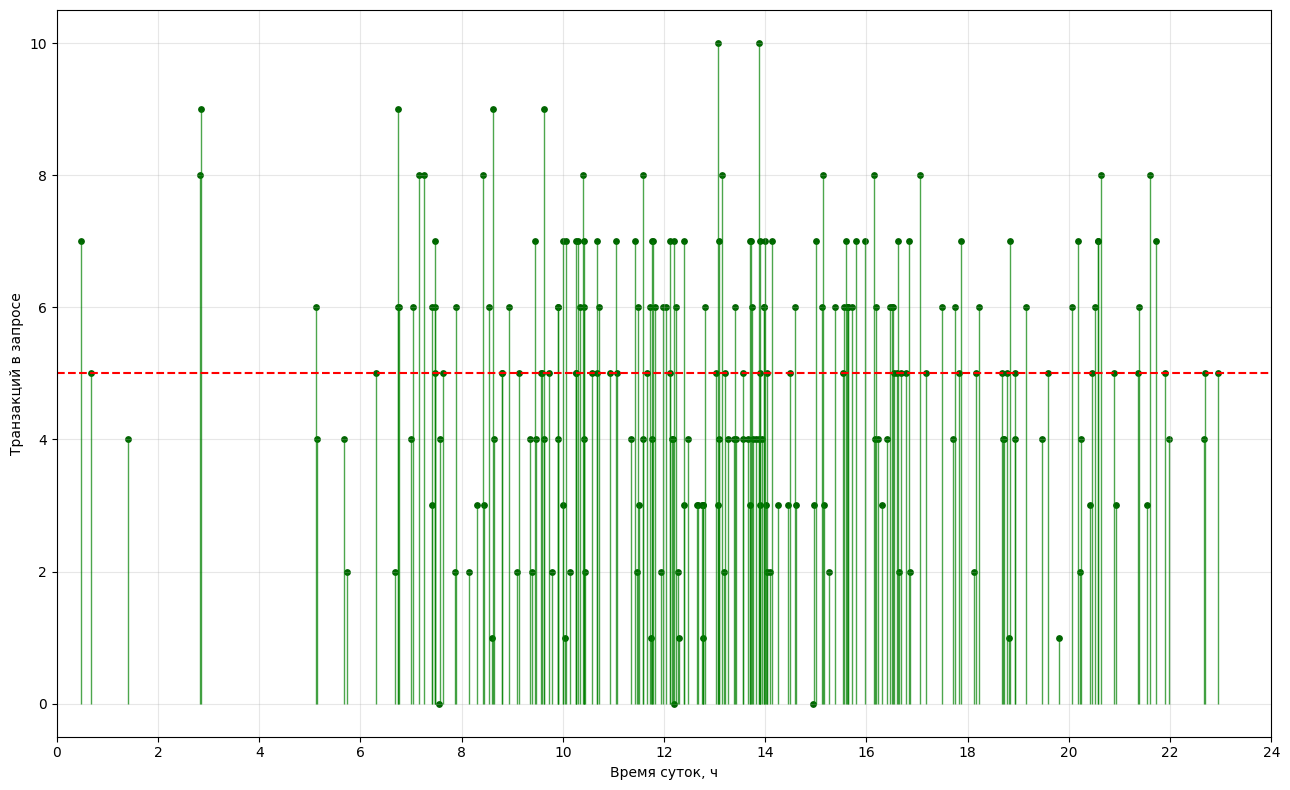

In [53]:
fig, ax = plt.subplots(figsize=(13, 8), sharex=True)
ax.vlines(accepted, 0, units, color='green', alpha=0.7, linewidth=1)
ax.scatter(accepted, units, color='darkgreen', s=15)
ax.axhline(Mx_w, color='red', linestyle='--')
ax.set_xlabel('Время суток, ч')
ax.set_ylabel('Транзакций в запросе')
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()